In [1]:
!nvidia-smi

Mon Jun 22 08:22:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# !git clone https://github.com/Omid-Nejati/Locality-iN-Locality.git

!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 64 (delta 20), reused 19 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 61.67 KiB | 10.28 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
pip install torchattacks

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  15.6M      0  0:00:16  0:00:16 --:--:-- 19.2M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  7938k      0  0:00:10  0:00:10 --:--:-- 9646k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  87025      0  0:00:01  0:00:01 --:--:-- 87080


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 15

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

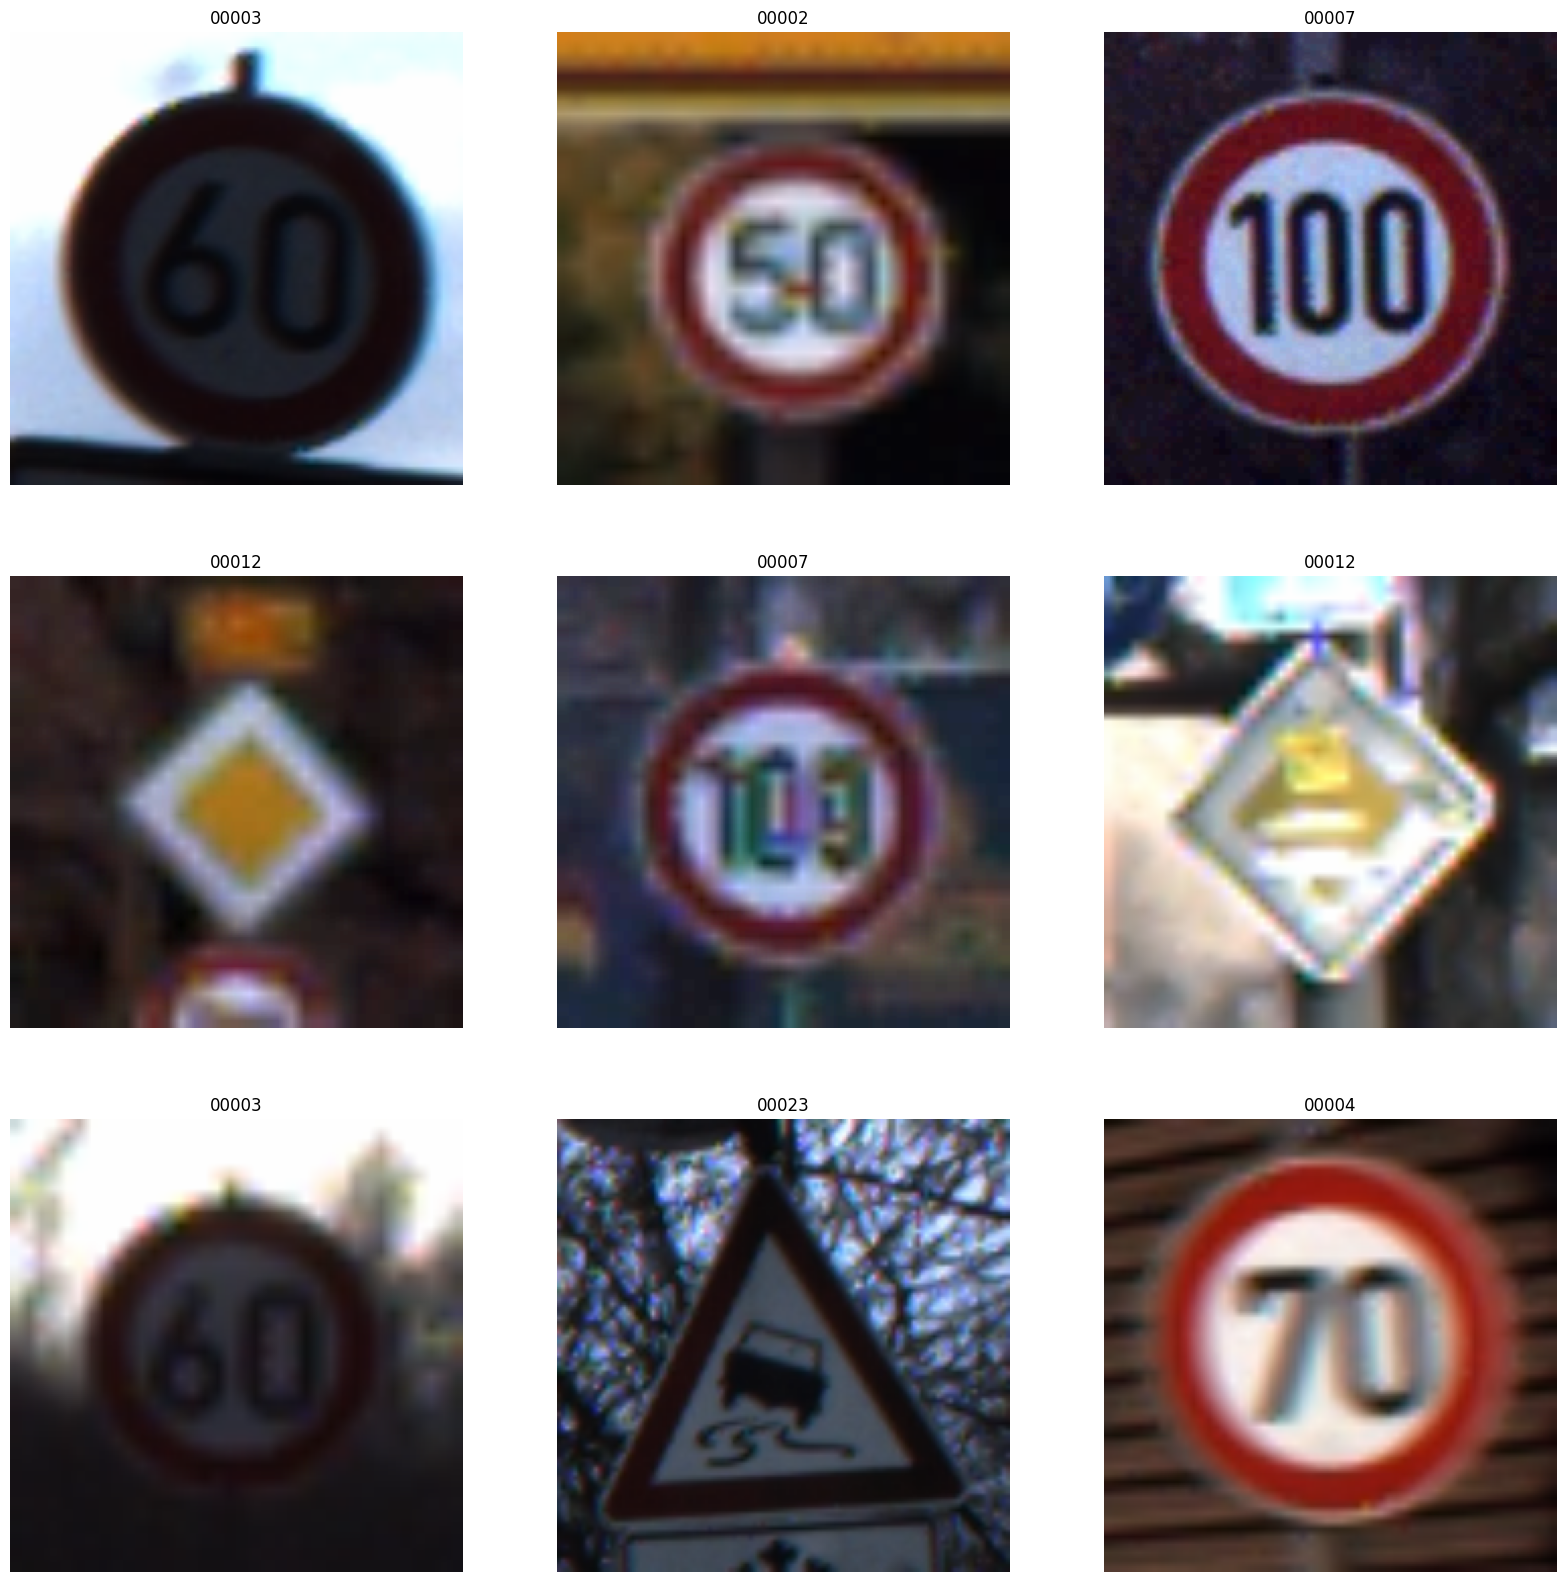

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
# from LNL import LNL_Ti as small

from LNL_TS import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=43, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [23]:
num_epochs = 5

In [24]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [25]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.028090
Epoch [1/5], lter [400/2613], Loss: 2.916889
Epoch [1/5], lter [600/2613], Loss: 2.973021
Epoch [1/5], lter [800/2613], Loss: 2.100071
Epoch [1/5], lter [1000/2613], Loss: 1.917468
Epoch [1/5], lter [1200/2613], Loss: 1.508237
Epoch [1/5], lter [1400/2613], Loss: 0.262471
Epoch [1/5], lter [1600/2613], Loss: 0.387846
Epoch [1/5], lter [1800/2613], Loss: 0.132591
Epoch [1/5], lter [2000/2613], Loss: 0.295760
Epoch [1/5], lter [2200/2613], Loss: 0.139711
Epoch [1/5], lter [2400/2613], Loss: 0.231120
Epoch [1/5], lter [2600/2613], Loss: 0.089330
Epoch [2/5], lter [200/2613], Loss: 0.009430
Epoch [2/5], lter [400/2613], Loss: 0.005739
Epoch [2/5], lter [600/2613], Loss: 0.046727
Epoch [2/5], lter [800/2613], Loss: 0.016993
Epoch [2/5], lter [1000/2613], Loss: 0.003593
Epoch [2/5], lter [1200/2613], Loss: 0.035544
Epoch [2/5], lter [1400/2613], Loss: 0.004156
Epoch [2/5], lter [1600/2613], Loss: 0.003349
Epoch [2/5], lter [1800/2613], Loss: 0.003

## Test

In [26]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 97.74 %


## FGSM attack

In [27]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 57.90 %


## PGD attack

In [28]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 35.01 %


## train LNL-MoEx

In [29]:
# from LNL_MoEx import LNL_MoEx_Ti as small
from LNL_TS import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [30]:
model = model.cuda()

In [31]:
import time
# time.clock_gettime()

In [32]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [33]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [34]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.131913
Epoch [1/5], lter [400/2613], Loss: 2.987785
Epoch [1/5], lter [600/2613], Loss: 2.574641
Epoch [1/5], lter [800/2613], Loss: 2.671780
Epoch [1/5], lter [1000/2613], Loss: 2.243070
Epoch [1/5], lter [1200/2613], Loss: 2.479695
Epoch [1/5], lter [1400/2613], Loss: 2.276449
Epoch [1/5], lter [1600/2613], Loss: 1.475784
Epoch [1/5], lter [1800/2613], Loss: 0.733374
Epoch [1/5], lter [2000/2613], Loss: 1.147075
Epoch [1/5], lter [2200/2613], Loss: 0.944902
Epoch [1/5], lter [2400/2613], Loss: 0.795318
Epoch [1/5], lter [2600/2613], Loss: 0.863872
Epoch [2/5], lter [200/2613], Loss: 0.625727
Epoch [2/5], lter [400/2613], Loss: 0.036095
Epoch [2/5], lter [600/2613], Loss: 0.065445
Epoch [2/5], lter [800/2613], Loss: 0.017126
Epoch [2/5], lter [1000/2613], Loss: 0.706430
Epoch [2/5], lter [1200/2613], Loss: 0.078755
Epoch [2/5], lter [1400/2613], Loss: 0.718977
Epoch [2/5], lter [1600/2613], Loss: 0.686553
Epoch [2/5], lter [1800/2613], Loss: 0.731

## Save pretrained model for submission

Run this after training the selected model. The saved `.pth` file is the pretrained model submitted with `LNL_TS.py`.


In [35]:
import os

os.makedirs('pretrained', exist_ok=True)
torch.save(model.state_dict(), 'pretrained/lnl_ts_ti_gtsrb.pth')
print('Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth')

Saved pretrained model to pretrained/lnl_ts_ti_gtsrb.pth


## Verify plug-and-play pretrained loading

This is the minimal checker code: same model file, local pretrained weights, then the original evaluation loop can be reused.


In [36]:
from LNL_TS import LNL_MoEx_Ti as small

model = small(pretrained=True)
model = model.cuda()
model.eval()
print('Loaded pretrained LNL-TS model successfully')

Loaded pretrained LNL-TS model successfully


## Number of Parameters

In [37]:
pip install ptflops

In [38]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-2a4utm32
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-2a4utm32
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [39]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


TrafficSignLNL(
  6.04 M, 99.371% Params, 1.24 GMac, 99.695% MACs, 
  (pixel_embed): PixelEmbed(
    648, 0.011% Params, 5.49 MMac, 0.440% MACs, 
    (proj): TrafficSignStem(
      648, 0.011% Params, 5.49 MMac, 0.440% MACs, 
      (conv1): Conv2d(324, 0.005% Params, 4.06 MMac, 0.326% MACs, 3, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(24, 0.000% Params, 301.06 KMac, 0.024% MACs, 12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): GELU(0, 0.000% Params, 150.53 KMac, 0.012% MACs, approximate='none')
      (dwconv): Conv2d(108, 0.002% Params, 338.69 KMac, 0.027% MACs, 12, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=12, bias=False)
      (bn2): BatchNorm2d(24, 0.000% Params, 75.26 KMac, 0.006% MACs, 12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): GELU(0, 0.000% Params, 37.63 KMac, 0.003% MACs, approximate='none')
      (pwconv): Conv2d(144, 0.002% Params, 451.